# Polywell Geometry Optimization — Minimizing Ion + Electron Leakage

This notebook investigates the **most leakage-resistant geometry** for a polywell
that has *two independent coil sets*:

- A 6-coil **B-field cage** (alternating currents, classic polywell topology) —
  confines electrons by magnetic mirroring at the boundary while leaving the
  central region near a magnetic null.
- A 6-coil **E-field cage** (uniformly charged rings) — creates an electrostatic
  potential structure that biases the boundary against one species or the other.
  Each coil set has its own diameter and offset, so the electric and magnetic
  cages can be sized independently.

## Physics: where do polywell particles actually leak?

A polywell's central region is essentially field-free. Particles bounce around
inside a magnetic well and an electrostatic well, and the loss channels are:

1. **Magnetic point/line cusps.** Where adjacent coil currents flow in opposite
   directions, the field lines pinch into "point cusps" (along the six face
   normals — the coil axes themselves) and "line cusps" (along the eight cube
   diagonals). These are *specific patches* on any spherical control surface
   where $|B|$ collapses, which means the local mirror ratio collapses, which
   means the local loss cone opens up. This is the dominant **electron** loss
   channel.

2. **Insufficient electrostatic barrier.** For the species whose charge the
   E-cage repels, leakage is set by the height of the potential barrier
   $\Delta\Phi = \Phi_{\text{boundary}} - \Phi(0)$ relative to that species'
   thermal energy. A particle with kinetic energy above $|q|\,\Delta\Phi$ walks
   straight out. This is the dominant **ion** loss channel (or electron, with
   the opposite sign convention).

So a "good" polywell geometry is one that simultaneously:

- Maximises the **mirror ratio** averaged over the boundary surface, and minimises
  the **fraction of that surface where the cusp lets the field collapse**, and
- Maximises the **electrostatic barrier** $\Delta\Phi$.

## What we vary

Six independent parameters split between the two cages:

| Cage | Strength | Diameter | Offset |
|-----:|:---------|:---------|:-------|
| B    | $I$ (A)  | $d_B$ (m) | $\ell_B$ (m) |
| E    | $Q$ (C/coil) | $d_E$ (m) | $\ell_E$ (m) |

The most interesting independent placement parameters are the two **offsets**
$\ell_B, \ell_E$ (where the coil rings sit relative to the origin). Diameters
matter too but for compactness we sweep offsets primarily and treat
diameters/strengths as fixed scales.

## What we compute

- $\mathbf{B}$ and $\mathbf{E}$ fields on a 3D Cartesian grid (vectorized analytic).
- **Loss-cone fraction** averaged on a control sphere — proxy for electron leakage.
- **Cusp area fraction** (solid angle on the boundary where $|B|$ is below a
  cutoff) — second proxy for electron leakage.
- **Electrostatic barrier** $\Delta\Phi$ — proxy for ion leakage.
- A combined **leakage figure of merit** $\mathcal{L}(\ell_B, \ell_E)$.

All output figures are written to `plots/` next to this notebook.

## 1. Setup

In [1]:
import os, sys, types
from pathlib import Path

# Make `src.*` imports work no matter where the notebook is launched from.
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR
while not (REPO_ROOT / "src").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

# Stub the google-auth modules `src.utils.storage` imports, since the notebook
# does not need a real backend. (Same pattern as E_Field_Analysis.ipynb.)
_GOOGLE_STUBS = [
    "google", "google.oauth2", "google.oauth2.credentials",
    "google.auth", "google.auth.transport", "google.auth.transport.requests",
    "googleapiclient", "googleapiclient.discovery", "googleapiclient.http",
    "googleapiclient.errors", "google_auth_oauthlib", "google_auth_oauthlib.flow",
]
for mod in _GOOGLE_STUBS:
    try:
        __import__(mod)
    except ImportError:
        sys.modules[mod] = types.ModuleType(mod)
sys.modules["google.oauth2.credentials"].Credentials = object
sys.modules["google.auth.transport.requests"].Request = object
if not hasattr(sys.modules["googleapiclient.discovery"], "build"):
    sys.modules["googleapiclient.discovery"].build = lambda *a, **k: None
sys.modules["googleapiclient.http"].MediaFileUpload = object
sys.modules["googleapiclient.http"].MediaIoBaseDownload = object
sys.modules["googleapiclient.errors"].HttpError = Exception
sys.modules["google_auth_oauthlib.flow"].InstalledAppFlow = object

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers projection)
from scipy.special import ellipk, ellipe

PLOTS_DIR = NB_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 7),
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

MU0 = 4e-7 * np.pi          # vacuum permeability  [T m / A]
EPS0 = 8.8541878128e-12     # vacuum permittivity  [F / m]

print(f"Repo root: {REPO_ROOT}")
print(f"Plots dir: {PLOTS_DIR}")

Repo root: /Users/yoonseongroh/PycharmProjects/WarpX
Plots dir: /Users/yoonseongroh/PycharmProjects/WarpX/tests/coil_field_analysis/plots


## 2. Vectorized field functions for an arbitrary 6-coil cage

Both the B-field cage and the E-field cage have the same
6-coil polywell topology — rings whose centers sit on the $\pm x, \pm y, \pm z$
faces of a cube of half-side $\ell$, each oriented with its axis pointing
through the cube center. The two cages differ only in:

- **B cage:** carries current $I$, with the *signed* per-coil current pattern
  matching `src.bext.analytic.POLYWELL_COILS` (alternating signs that produce
  the correct cusp topology).
- **E cage:** carries charge $Q$ on every ring with the *same* sign — a
  uniformly-charged shell of rings produces the deepest monotonic potential
  well and is what the original WarpX `eext` pipeline implements.

Below we define:

- `B_polywell_param(X, Y, Z, I, dia, offset)` — total $\mathbf{B}$ from the
  6-coil cage. Uses the same elliptic-integral kernel as `src.bext.analytic`.
- `E_polywell_param(X, Y, Z, Q, dia, offset)` — total $\mathbf{E}$.
- `phi_polywell_param(X, Y, Z, Q, dia, offset)` — scalar potential $\Phi$, used
  to measure the electrostatic barrier.

All three are fully vectorized: pass arrays of any shape, get arrays back.

In [2]:
# ---------------------------------------------------------------
# B-field: elliptic-integral kernel (vectorized)
# ---------------------------------------------------------------

def _B_loop_axisymm(rho, z, a, I):
    """B_rho, B_z from a single Z-axis loop of radius `a`, current `I`."""
    rho_safe = np.where(np.abs(rho) < 1e-15, 1e-15, rho)
    alpha2 = (rho_safe - a)**2 + z**2
    beta2  = (rho_safe + a)**2 + z**2
    k2 = np.clip(4 * a * rho_safe / beta2, 0, 1 - 1e-15)
    K = ellipk(k2)
    E = ellipe(k2)
    C = MU0 * I / (2 * np.pi)
    sb = np.sqrt(beta2)
    Bz = C / sb * (K + (a**2 - rho_safe**2 - z**2) / alpha2 * E)
    Br = C * z / (rho_safe * sb) * (-K + (a**2 + rho_safe**2 + z**2) / alpha2 * E)
    Br = np.where(np.abs(rho) < 1e-12, 0.0, Br)
    return Br, Bz

# Canonical polywell coil layout: every axis-pair is antisymmetric, so each pair
# is "facing" (same magnetic pole pointed at the origin). This makes B(0) = 0
# exactly by pair-cancellation along every axis. Note: this differs from
# `src.bext.analytic.POLYWELL_COILS`, which has a same-sign Z-pair (Helmholtz-like)
# and therefore does NOT vanish at origin — that pattern is fine for the existing
# field-loading pipeline but it isn't the right starting point for an
# optimization study, where we want the canonical polywell topology.
_B_COILS = [
    ("x", -1,  1), ("x",  1, -1),
    ("y", -1,  1), ("y",  1, -1),
    ("z", -1,  1), ("z",  1, -1),
]

def _project_loop(axis, X, Y, Z, pos, a, I_signed):
    """Cartesian B-components from one loop centered on `axis` at `pos`."""
    if axis == "z":
        rho = np.sqrt(X**2 + Y**2); theta = np.arctan2(Y, X); zeta = Z - pos
        Br, Bax = _B_loop_axisymm(rho, zeta, a, I_signed)
        return Br * np.cos(theta), Br * np.sin(theta), Bax
    if axis == "x":
        rho = np.sqrt(Z**2 + Y**2); theta = np.arctan2(Y, Z); zeta = X - pos
        Br, Bax = _B_loop_axisymm(rho, zeta, a, I_signed)
        return Bax, Br * np.sin(theta), Br * np.cos(theta)
    if axis == "y":
        rho = np.sqrt(Z**2 + X**2); theta = np.arctan2(X, Z); zeta = Y - pos
        Br, Bax = _B_loop_axisymm(rho, zeta, a, I_signed)
        return Br * np.sin(theta), Bax, Br * np.cos(theta)
    raise ValueError(axis)

def B_polywell_param(X, Y, Z, I, dia, offset):
    """6-coil polywell B-field, parametrised by current, diameter, offset."""
    a = dia / 2
    X = np.asarray(X, float); Y = np.asarray(Y, float); Z = np.asarray(Z, float)
    Bx = np.zeros_like(X); By = np.zeros_like(X); Bz = np.zeros_like(X)
    for axis, pos_sign, I_sign in _B_COILS:
        bx, by, bz = _project_loop(axis, X, Y, Z, pos_sign * offset, a, I_sign * I)
        Bx += bx; By += by; Bz += bz
    return Bx, By, Bz


# ---------------------------------------------------------------
# E-field and scalar potential from a uniformly-charged ring
# ---------------------------------------------------------------
# Closed forms in terms of complete elliptic integrals K and E:
#
#   Phi(rho, z) = Q / (4 pi eps0)  *  (1 / (pi * sqrt((a+rho)^2 + z^2)))  *  K(m)
#   E_z(rho, z) = Q / (4 pi eps0)  *  z / (pi * a2*b * something)         (see code)
#
# We use a vectorized azimuthal quadrature for E (matches `src.eext.methods.fw_e`)
# and the elliptic-K closed form for the potential.

def _Phi_ring_axisymm(rho, z, a, Q):
    """Scalar potential from a charged ring of radius `a`, total charge `Q`.

    Closed-form result (e.g. Smythe, "Static and Dynamic Electricity"):

        Phi(rho, z) = Q / (2 pi^2 eps0 sqrt((a+rho)^2 + z^2)) * K(m)
        m = 4 a rho / ((a+rho)^2 + z^2)

    On-axis (rho = 0): m = 0, K(0) = pi/2, so this reduces to the textbook
    Q / (4 pi eps0 sqrt(a^2 + z^2)).
    """
    s = (a + rho)**2 + z**2
    m = np.clip(4 * a * rho / s, 0, 1 - 1e-12)
    K = ellipk(m)
    return Q / (2 * np.pi**2 * EPS0 * np.sqrt(s)) * K

def _E_ring_axisymm(rho, z, a, Q, n_theta=120):
    """E_rho, E_z from a charged ring (vectorized periodic quadrature in theta)."""
    lam = Q / (2 * np.pi * a)
    theta = np.linspace(0, 2 * np.pi, n_theta, endpoint=False)
    cos_t = np.cos(theta)
    rho_e = rho[..., None]
    z_e   = z[..., None]
    D = np.sqrt(rho_e**2 + a**2 - 2 * a * rho_e * cos_t + z_e**2)
    iEr = np.sum((rho_e - a * cos_t) / D**3, axis=-1) * (2 * np.pi / n_theta)
    iEz = np.sum(1.0 / D**3, axis=-1) * (2 * np.pi / n_theta)
    coef = lam * a / (4 * np.pi * EPS0)
    return coef * iEr, coef * z * iEz

# E coils all carry the same charge sign — uniform shell of rings.
_E_COILS = [("x", -1), ("x", 1), ("y", -1), ("y", 1), ("z", -1), ("z", 1)]

def _project_ring(axis, X, Y, Z, pos, a, Q, kernel):
    """Project an axisymmetric ring kernel into Cartesian lab components."""
    if axis == "z":
        rho = np.sqrt(X**2 + Y**2); theta = np.arctan2(Y, X); zeta = Z - pos
    elif axis == "x":
        rho = np.sqrt(Z**2 + Y**2); theta = np.arctan2(Y, Z); zeta = X - pos
    else:  # 'y'
        rho = np.sqrt(Z**2 + X**2); theta = np.arctan2(X, Z); zeta = Y - pos
    out = kernel(rho, zeta, a, Q)
    if not isinstance(out, tuple):
        return out                              # scalar (potential)
    Er, Eax = out
    if axis == "z":
        return Er * np.cos(theta), Er * np.sin(theta), Eax
    if axis == "x":
        return Eax, Er * np.sin(theta), Er * np.cos(theta)
    return Er * np.sin(theta), Eax, Er * np.cos(theta)

def E_polywell_param(X, Y, Z, Q, dia, offset):
    """6-coil polywell E-field, parametrised by per-coil charge, diameter, offset."""
    a = dia / 2
    X = np.asarray(X, float); Y = np.asarray(Y, float); Z = np.asarray(Z, float)
    Ex = np.zeros_like(X); Ey = np.zeros_like(X); Ez = np.zeros_like(X)
    for axis, pos_sign in _E_COILS:
        ex, ey, ez = _project_ring(axis, X, Y, Z, pos_sign * offset,
                                    a, Q, _E_ring_axisymm)
        Ex += ex; Ey += ey; Ez += ez
    return Ex, Ey, Ez

def phi_polywell_param(X, Y, Z, Q, dia, offset):
    """6-coil polywell scalar potential."""
    a = dia / 2
    X = np.asarray(X, float); Y = np.asarray(Y, float); Z = np.asarray(Z, float)
    Phi = np.zeros_like(X)
    for axis, pos_sign in _E_COILS:
        Phi = Phi + _project_ring(axis, X, Y, Z, pos_sign * offset,
                                   a, Q, _Phi_ring_axisymm)
    return Phi

print("Field functions defined: B_polywell_param, E_polywell_param, phi_polywell_param")

Field functions defined: B_polywell_param, E_polywell_param, phi_polywell_param


## 3. Quick sanity checks on the field functions

Two cheap correctness checks before we build metrics on
top of these functions:

- $\mathbf{B}$ at the origin must vanish — the alternating-current polywell
  has a magnetic null at the center.
- The scalar potential $\Phi$ from the closed-form elliptic-K expression
  must agree with $-\int \mathbf{E}\cdot d\boldsymbol\ell$ from the
  numerical-quadrature `E_polywell_param`. We integrate along the $+z$ axis
  from a far point inward and compare to $\Phi$ at the origin (with the
  far-field as the reference).

|B(0)| = 0.00e+00  T  (should be ~0)
max |Phi(closed-form) - Phi(int E)| / max|Phi| = 7.20e-07  (should be small)


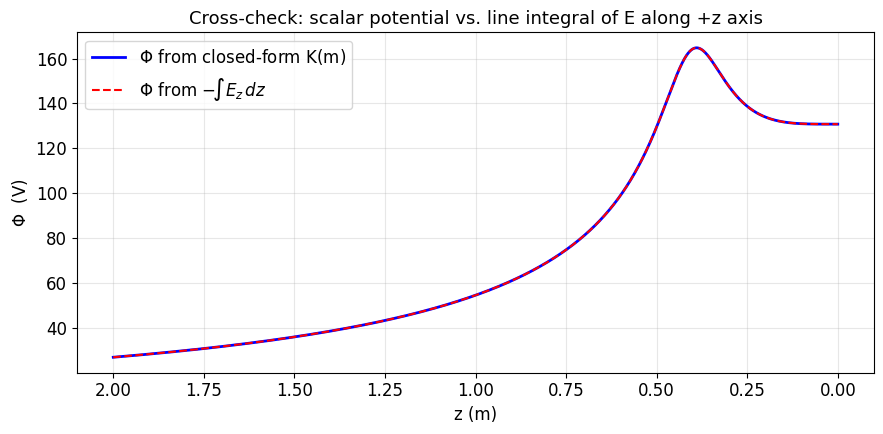

In [3]:
# 3a) B at origin == 0
Bx0, By0, Bz0 = B_polywell_param(np.array([0.0]), np.array([0.0]), np.array([0.0]),
                                  I=1e6, dia=1.0, offset=1.1)
print(f"|B(0)| = {np.sqrt(Bx0**2+By0**2+Bz0**2)[0]:.2e}  T  (should be ~0)")

# 3b) Phi consistency: -int E_z dz from far away should match Phi - Phi(far)
Q_test = 1e-9
dia_test = 0.2
off_test = 0.4
z_line = np.linspace(2.0, 0.0, 5000)             # integrate inward
xL = np.zeros_like(z_line); yL = np.zeros_like(z_line)

_, _, Ez_line = E_polywell_param(xL, yL, z_line, Q=Q_test, dia=dia_test, offset=off_test)
Phi_line = phi_polywell_param(xL, yL, z_line,    Q=Q_test, dia=dia_test, offset=off_test)

# trapezoidal integral of -E_z from z_line[0] (far end) to each interior point
dz = np.diff(z_line)
phi_from_E = np.concatenate([[0.0], -np.cumsum(0.5 * (Ez_line[:-1] + Ez_line[1:]) * dz)])
phi_from_E_shifted = phi_from_E + Phi_line[0]    # match reference at far end

err = np.max(np.abs(phi_from_E_shifted - Phi_line)) / np.max(np.abs(Phi_line))
print(f"max |Phi(closed-form) - Phi(int E)| / max|Phi| = {err:.2e}  (should be small)")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(z_line, Phi_line,            "b-",  lw=2.0, label=r"$\Phi$ from closed-form K(m)")
ax.plot(z_line, phi_from_E_shifted,  "r--", lw=1.5, label=r"$\Phi$ from $-\!\int E_z\,dz$")
ax.set_xlabel("z (m)"); ax.set_ylabel(r"$\Phi$  (V)")
ax.set_title("Cross-check: scalar potential vs. line integral of E along +z axis")
ax.legend(); ax.grid(alpha=0.3); ax.invert_xaxis()
plt.tight_layout(); plt.savefig(PLOTS_DIR / "polyopt_00_sanity.png", dpi=150); plt.show()

## 4. Defining the leakage metrics

We evaluate every metric on a **control sphere** of radius
$R$, sampled by a Fibonacci/spherical grid of $N_s$ points. $R$ is the radius
of the imagined "edge of the plasma volume" — typically just inside the
smaller of the two cage offsets so we are scoring the field as seen by a
particle that has *just* reached the boundary.

### Electron metrics

A particle at radius $R$ moving with pitch angle $\theta$ (angle between
$\mathbf{v}$ and $\mathbf{B}$) is mirror-confined unless

$$\sin^2 \theta < \frac{|B|_{\text{local}}}{|B|_{\max}}\,,$$

where $|B|_{\max}$ is the largest field strength the particle's flux tube
threads (we approximate by the maximum of $|B|$ over the sphere — the field
peaks where the coil rings sit). The fraction of an isotropic velocity
distribution lost to the loss cone is

$$f_{\text{loss}}(\hat n) = 1 - \sqrt{1 - \frac{|B|_{\text{local}}(\hat n)}{|B|_{\max}}}\,.$$

We average $f_{\text{loss}}$ over the sphere, weighted by surface area, to get
$\langle f_{\text{loss}} \rangle$ — call this the **loss-cone fraction**.

Separately, the **cusp area fraction** $A_{\text{cusp}}/A_{\text{tot}}$ is the
solid-angle fraction where $|B|_{\text{local}} < \alpha |B|_{\max}$ for some
threshold $\alpha$ (default 0.3). A point cusp shows up as a tight patch
where this fraction concentrates.

### Ion metric

The ion barrier is

$$\Delta\Phi = \langle \Phi \rangle_{\text{sphere}} - \Phi(0)\,,$$

with sign chosen so that *positive* $\Delta\Phi$ confines positive charges. A
sphere-average is more honest than a point sample because $\Phi$ is not exactly
constant on a sphere when the cage is finite-radius.

In [4]:
def fibonacci_sphere(N):
    """N points roughly uniformly distributed on the unit sphere."""
    i = np.arange(N) + 0.5
    phi = np.arccos(1.0 - 2.0 * i / N)         # polar
    psi = np.pi * (1.0 + np.sqrt(5.0)) * i     # azimuth
    x = np.sin(phi) * np.cos(psi)
    y = np.sin(phi) * np.sin(psi)
    z = np.cos(phi)
    return x, y, z

def evaluate_on_sphere(R, N=2000, *, I, dia_B, offset_B, Q, dia_E, offset_E):
    """Sample B, |B|, Phi on a sphere of radius R."""
    nx, ny, nz = fibonacci_sphere(N)
    X = R * nx; Y = R * ny; Z = R * nz
    Bx, By, Bz = B_polywell_param(X, Y, Z, I=I, dia=dia_B, offset=offset_B)
    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)
    Phi  = phi_polywell_param(X, Y, Z, Q=Q, dia=dia_E, offset=offset_E)
    return {"nhat": np.stack([nx, ny, nz], axis=1),
            "Bmag": Bmag, "Phi": Phi}

def leakage_metrics(R, *, I, dia_B, offset_B, Q, dia_E, offset_E,
                    N_sphere=2000, cusp_alpha=0.3):
    """Compute electron/ion leakage proxies on a control sphere of radius R."""
    s = evaluate_on_sphere(R, N=N_sphere,
                            I=I, dia_B=dia_B, offset_B=offset_B,
                            Q=Q, dia_E=dia_E, offset_E=offset_E)
    Bmag = s["Bmag"]; Phi = s["Phi"]
    Bmax = Bmag.max()
    # Loss-cone fraction (per direction)
    ratio = np.clip(Bmag / Bmax, 0.0, 1.0)
    f_loss = 1.0 - np.sqrt(1.0 - ratio)
    # Cusp area fraction = sphere fraction below alpha * Bmax
    A_cusp = float(np.mean(Bmag < cusp_alpha * Bmax))
    # Ion barrier vs origin
    Phi0 = phi_polywell_param(np.array([0.0]), np.array([0.0]), np.array([0.0]),
                               Q=Q, dia=dia_E, offset=offset_E)[0]
    Phi_avg = float(Phi.mean())
    dPhi = Phi_avg - Phi0
    return {
        "Bmin":    float(Bmag.min()),
        "Bmax":    float(Bmax),
        "Bmean":   float(Bmag.mean()),
        "loss_cone": float(f_loss.mean()),
        "cusp_area": A_cusp,
        "dPhi":     float(dPhi),
        "Phi0":     float(Phi0),
        "Phi_avg":  Phi_avg,
        "sphere":   s,
    }

# Smoke-test on a baseline configuration
m_baseline = leakage_metrics(R=0.30,
                              I=1e6, dia_B=1.0, offset_B=0.55,
                              Q=1e-9, dia_E=0.2, offset_E=0.40)
print("Baseline metrics:")
for k, v in m_baseline.items():
    if k == "sphere": continue
    print(f"  {k:>10s} = {v:+.4e}")

Baseline metrics:
        Bmin = +2.2612e-02
        Bmax = +1.2094e-01
       Bmean = +8.6756e-02
   loss_cone = +4.9708e-01
   cusp_area = +3.1500e-02
        dPhi = -5.7950e-06
        Phi0 = +1.3079e+02
     Phi_avg = +1.3079e+02


## 5. Baseline geometry — fields and metrics laid out side by side

Pick a reference geometry, then visualize:

- **Top row:** The B-cage and E-cage rings in 3D, color-coded.
- **Middle row:** $\log_{10}|B|$ in the XZ midplane, $\log_{10}|E|$ in the XZ
  midplane, and $\Phi$ along the $+x$ axis (with the position of the E-cage
  rings marked).
- **Bottom row:** $|B|$ on the control sphere unrolled to $(\theta, \phi)$.
  Cusp patches (low-$|B|$) appear as dark wells. The annotated locations of
  the six coil-axis "point cusps" should land in those wells.

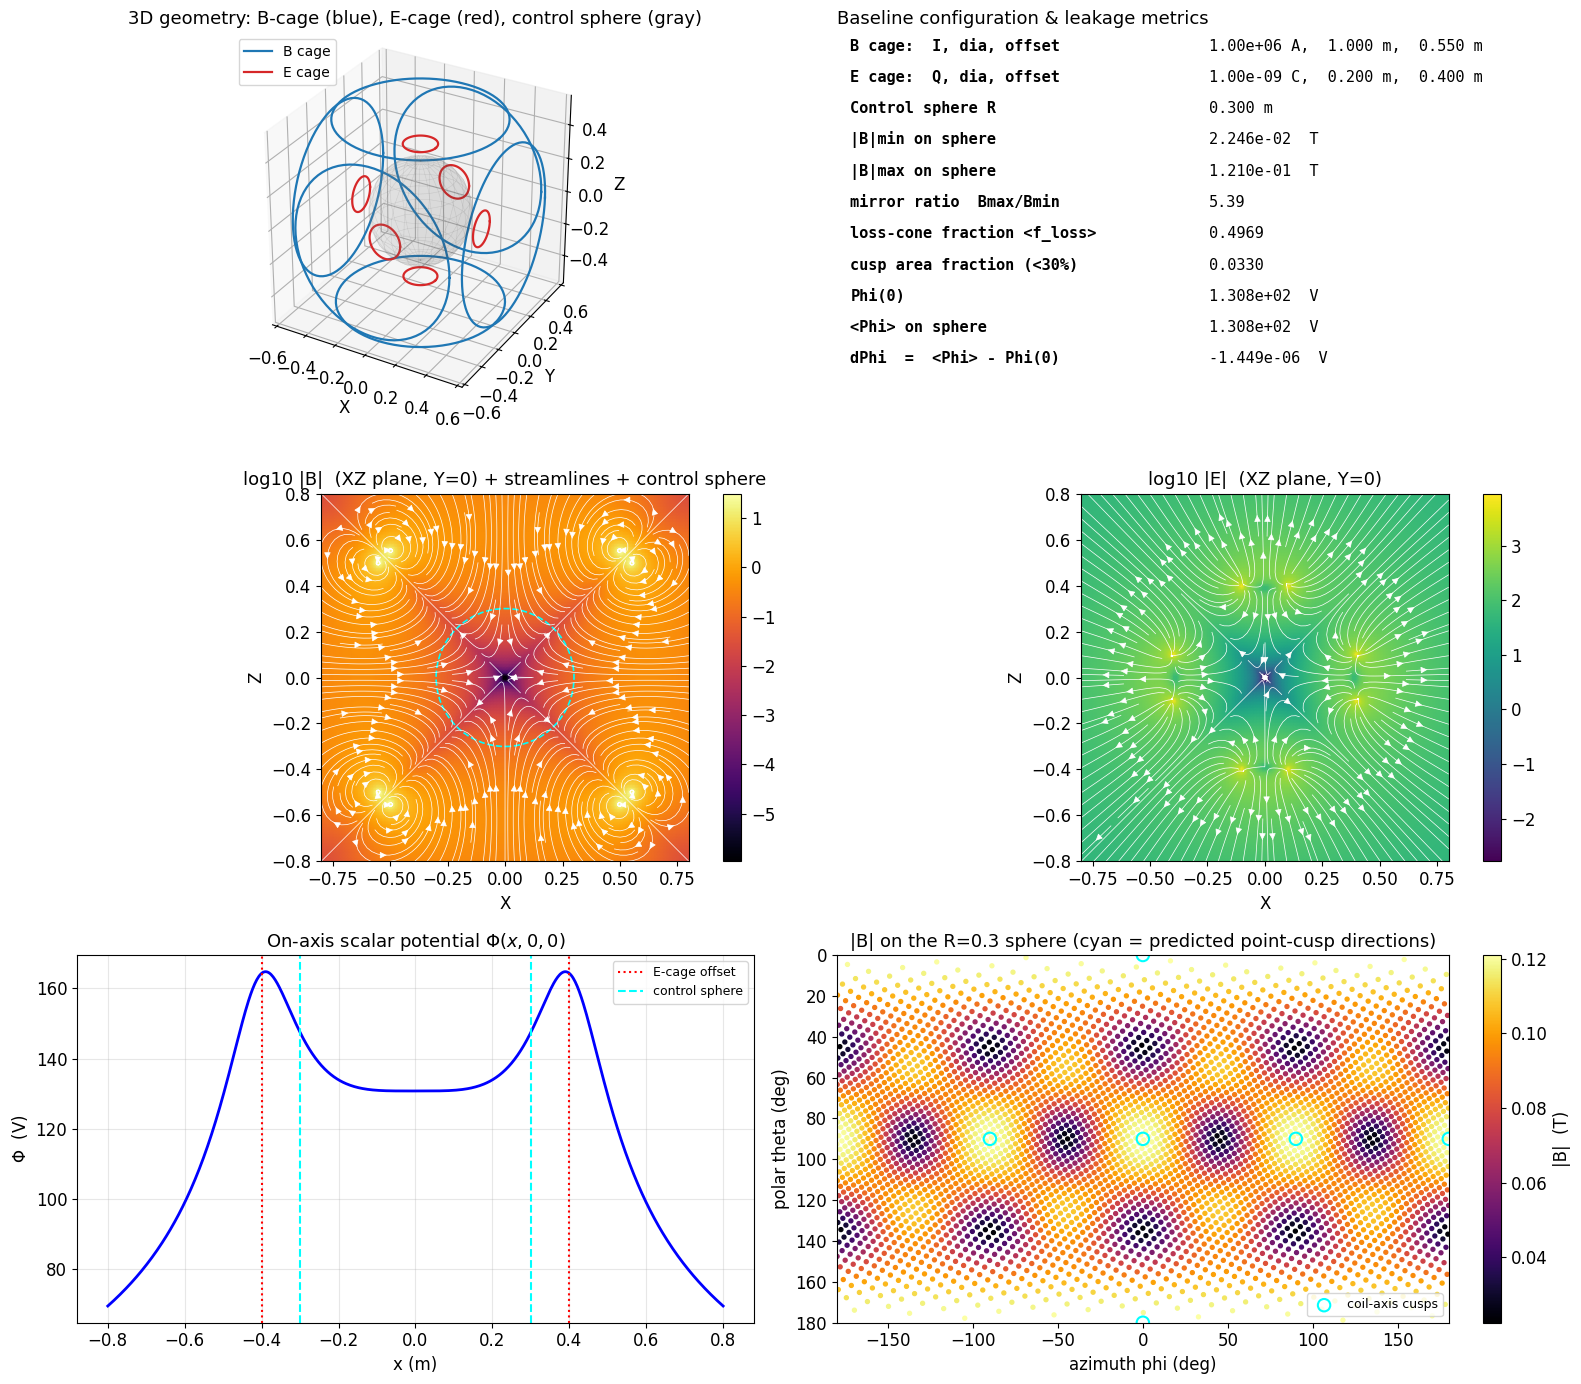

In [5]:
def draw_polywell_rings(ax, dia, offset, color, label, lw=1.6):
    """Draw the 6 rings of one polywell cage on a 3D axis."""
    a = dia / 2
    t = np.linspace(0, 2 * np.pi, 80)
    rings = []
    # Three pairs, one per axis; each ring perpendicular to its axis
    for axis, pos in [("x", -offset), ("x", offset),
                      ("y", -offset), ("y", offset),
                      ("z", -offset), ("z", offset)]:
        if axis == "x":
            ring = np.array([np.full_like(t, pos), a * np.cos(t), a * np.sin(t)])
        elif axis == "y":
            ring = np.array([a * np.cos(t), np.full_like(t, pos), a * np.sin(t)])
        else:
            ring = np.array([a * np.cos(t), a * np.sin(t), np.full_like(t, pos)])
        rings.append(ring)
        ax.plot(ring[0], ring[1], ring[2], color=color, lw=lw)
    # Add a single legend handle by drawing an off-screen marker
    ax.plot([], [], [], color=color, lw=lw, label=label)
    return rings

# --- baseline parameters ---
PARAMS = dict(I=1e6, dia_B=1.0, offset_B=0.55,
               Q=1e-9, dia_E=0.20, offset_E=0.40)
R_CTRL = 0.30                                  # control sphere radius

# --- pre-compute a 2D field slice for plotting ---
N2 = 120
ax_grid = np.linspace(-0.8, 0.8, N2)
X2, Z2 = np.meshgrid(ax_grid, ax_grid, indexing="xy")
Y2 = np.zeros_like(X2)
Bx2, By2, Bz2 = B_polywell_param(X2, Y2, Z2,
                                  I=PARAMS["I"], dia=PARAMS["dia_B"],
                                  offset=PARAMS["offset_B"])
Ex2, Ey2, Ez2 = E_polywell_param(X2, Y2, Z2,
                                  Q=PARAMS["Q"], dia=PARAMS["dia_E"],
                                  offset=PARAMS["offset_E"])
Bmag2 = np.sqrt(Bx2**2 + By2**2 + Bz2**2)
Emag2 = np.sqrt(Ex2**2 + Ey2**2 + Ez2**2)

# --- on-axis potential profile ---
x_line = np.linspace(-0.8, 0.8, 600)
zL = np.zeros_like(x_line); yL = np.zeros_like(x_line)
Phi_line = phi_polywell_param(x_line, yL, zL,
                               Q=PARAMS["Q"], dia=PARAMS["dia_E"],
                               offset=PARAMS["offset_E"])

# --- sphere |B| map ---
m = leakage_metrics(R=R_CTRL, **PARAMS, N_sphere=4000)
nhat = m["sphere"]["nhat"]
Bsphere = m["sphere"]["Bmag"]
theta_s = np.arccos(np.clip(nhat[:, 2], -1, 1))
phi_s   = np.arctan2(nhat[:, 1], nhat[:, 0])

# --- assemble the figure ---
fig = plt.figure(figsize=(16, 14))

# Top row: 3D cage geometry
ax3d = fig.add_subplot(3, 2, 1, projection="3d")
draw_polywell_rings(ax3d, PARAMS["dia_B"], PARAMS["offset_B"], "tab:blue", "B cage")
draw_polywell_rings(ax3d, PARAMS["dia_E"], PARAMS["offset_E"], "tab:red",  "E cage")
# control sphere wireframe
u, v = np.mgrid[0:2*np.pi:24j, 0:np.pi:13j]
ax3d.plot_surface(R_CTRL*np.cos(u)*np.sin(v),
                   R_CTRL*np.sin(u)*np.sin(v),
                   R_CTRL*np.cos(v),
                   color="0.6", alpha=0.08, edgecolor="0.4", linewidth=0.4)
ax3d.set_title("3D geometry: B-cage (blue), E-cage (red), control sphere (gray)")
ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")
ax3d.set_box_aspect([1,1,1]); ax3d.legend(loc="upper left", fontsize=10)

# Top-right: the metric values for this configuration as a table
ax_tbl = fig.add_subplot(3, 2, 2)
ax_tbl.axis("off")
rows = [
    ["B cage:  I, dia, offset",     f"{PARAMS['I']:.2e} A,  {PARAMS['dia_B']:.3f} m,  {PARAMS['offset_B']:.3f} m"],
    ["E cage:  Q, dia, offset",     f"{PARAMS['Q']:.2e} C,  {PARAMS['dia_E']:.3f} m,  {PARAMS['offset_E']:.3f} m"],
    ["Control sphere R",            f"{R_CTRL:.3f} m"],
    ["|B|min on sphere",            f"{m['Bmin']:.3e}  T"],
    ["|B|max on sphere",            f"{m['Bmax']:.3e}  T"],
    ["mirror ratio  Bmax/Bmin",     f"{(m['Bmax']/max(m['Bmin'],1e-30)):.2f}"],
    ["loss-cone fraction <f_loss>", f"{m['loss_cone']:.4f}"],
    ["cusp area fraction (<30%)",   f"{m['cusp_area']:.4f}"],
    ["Phi(0)",                      f"{m['Phi0']:.3e}  V"],
    ["<Phi> on sphere",             f"{m['Phi_avg']:.3e}  V"],
    ["dPhi  =  <Phi> - Phi(0)",     f"{m['dPhi']:+.3e}  V"],
]
y = 0.95
for label, val in rows:
    ax_tbl.text(0.02, y, label, fontfamily="monospace", fontsize=11, weight="bold",
                transform=ax_tbl.transAxes)
    ax_tbl.text(0.55, y, val,   fontfamily="monospace", fontsize=11,
                transform=ax_tbl.transAxes)
    y -= 0.085
ax_tbl.set_title("Baseline configuration & leakage metrics", loc="left", fontsize=13)

# Middle-left: |B| in XZ
ax = fig.add_subplot(3, 2, 3)
pcm = ax.pcolormesh(ax_grid, ax_grid, np.log10(Bmag2 + 1e-30),
                     cmap="inferno", shading="gouraud")
ax.streamplot(ax_grid, ax_grid, Bx2, Bz2, color="white",
               linewidth=0.5, density=2.0)
circle = plt.Circle((0, 0), R_CTRL, fill=False, edgecolor="cyan", lw=1.2, ls="--")
ax.add_patch(circle)
ax.set_title("log10 |B|  (XZ plane, Y=0) + streamlines + control sphere")
ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_aspect("equal")
plt.colorbar(pcm, ax=ax, fraction=0.046)

# Middle-right: |E| in XZ
ax = fig.add_subplot(3, 2, 4)
pcm = ax.pcolormesh(ax_grid, ax_grid, np.log10(Emag2 + 1e-30),
                     cmap="viridis", shading="gouraud")
ax.streamplot(ax_grid, ax_grid, Ex2, Ez2, color="white",
               linewidth=0.5, density=2.0)
ax.set_title("log10 |E|  (XZ plane, Y=0)")
ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_aspect("equal")
plt.colorbar(pcm, ax=ax, fraction=0.046)

# Bottom-left: Phi(x) along +x axis
ax = fig.add_subplot(3, 2, 5)
ax.plot(x_line, Phi_line, "b-", lw=2)
ax.axvline( PARAMS["offset_E"], color="red",  ls=":",  label="E-cage offset")
ax.axvline(-PARAMS["offset_E"], color="red",  ls=":")
ax.axvline( R_CTRL,             color="cyan", ls="--", label="control sphere")
ax.axvline(-R_CTRL,             color="cyan", ls="--")
ax.set_xlabel("x (m)"); ax.set_ylabel(r"$\Phi$  (V)")
ax.set_title(r"On-axis scalar potential $\Phi(x, 0, 0)$")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# Bottom-right: |B| on the sphere, unrolled
ax = fig.add_subplot(3, 2, 6)
sc = ax.scatter(np.degrees(phi_s), np.degrees(theta_s),
                c=Bsphere, s=8, cmap="inferno")
plt.colorbar(sc, ax=ax, fraction=0.046, label="|B|  (T)")
# The 6 face-normal point-cusp directions
cusps = [(0, 90), (180, 90), (-90, 90), (90, 90), (0, 0), (0, 180)]
ax.scatter([p for p, _ in cusps], [t for _, t in cusps],
           facecolor="none", edgecolor="cyan", s=80, lw=1.5,
           label="coil-axis cusps")
ax.set_xlabel("azimuth phi (deg)"); ax.set_ylabel("polar theta (deg)")
ax.set_title(f"|B| on the R={R_CTRL} sphere (cyan = predicted point-cusp directions)")
ax.set_xlim(-180, 180); ax.set_ylim(0, 180); ax.invert_yaxis()
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "polyopt_01_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 1D parameter sweeps — what does each knob actually do?

Hold every other parameter at the baseline and sweep one
knob at a time:

1. **B-cage offset $\ell_B$** — how far the field-cage rings sit from origin.
   Smaller offset → tighter, stronger field but larger loss-cone (rings push
   into the plasma volume); larger offset → weaker field at the boundary.
2. **E-cage offset $\ell_E$** — same idea for the electrostatic side. Affects
   $\Delta\Phi$.
3. **Control sphere radius $R$** — sanity check: where do the metrics
   *plateau*? That tells us a sensible operating $R$ (i.e., the radius at
   which we score the geometry shouldn't be thrashing the conclusion).

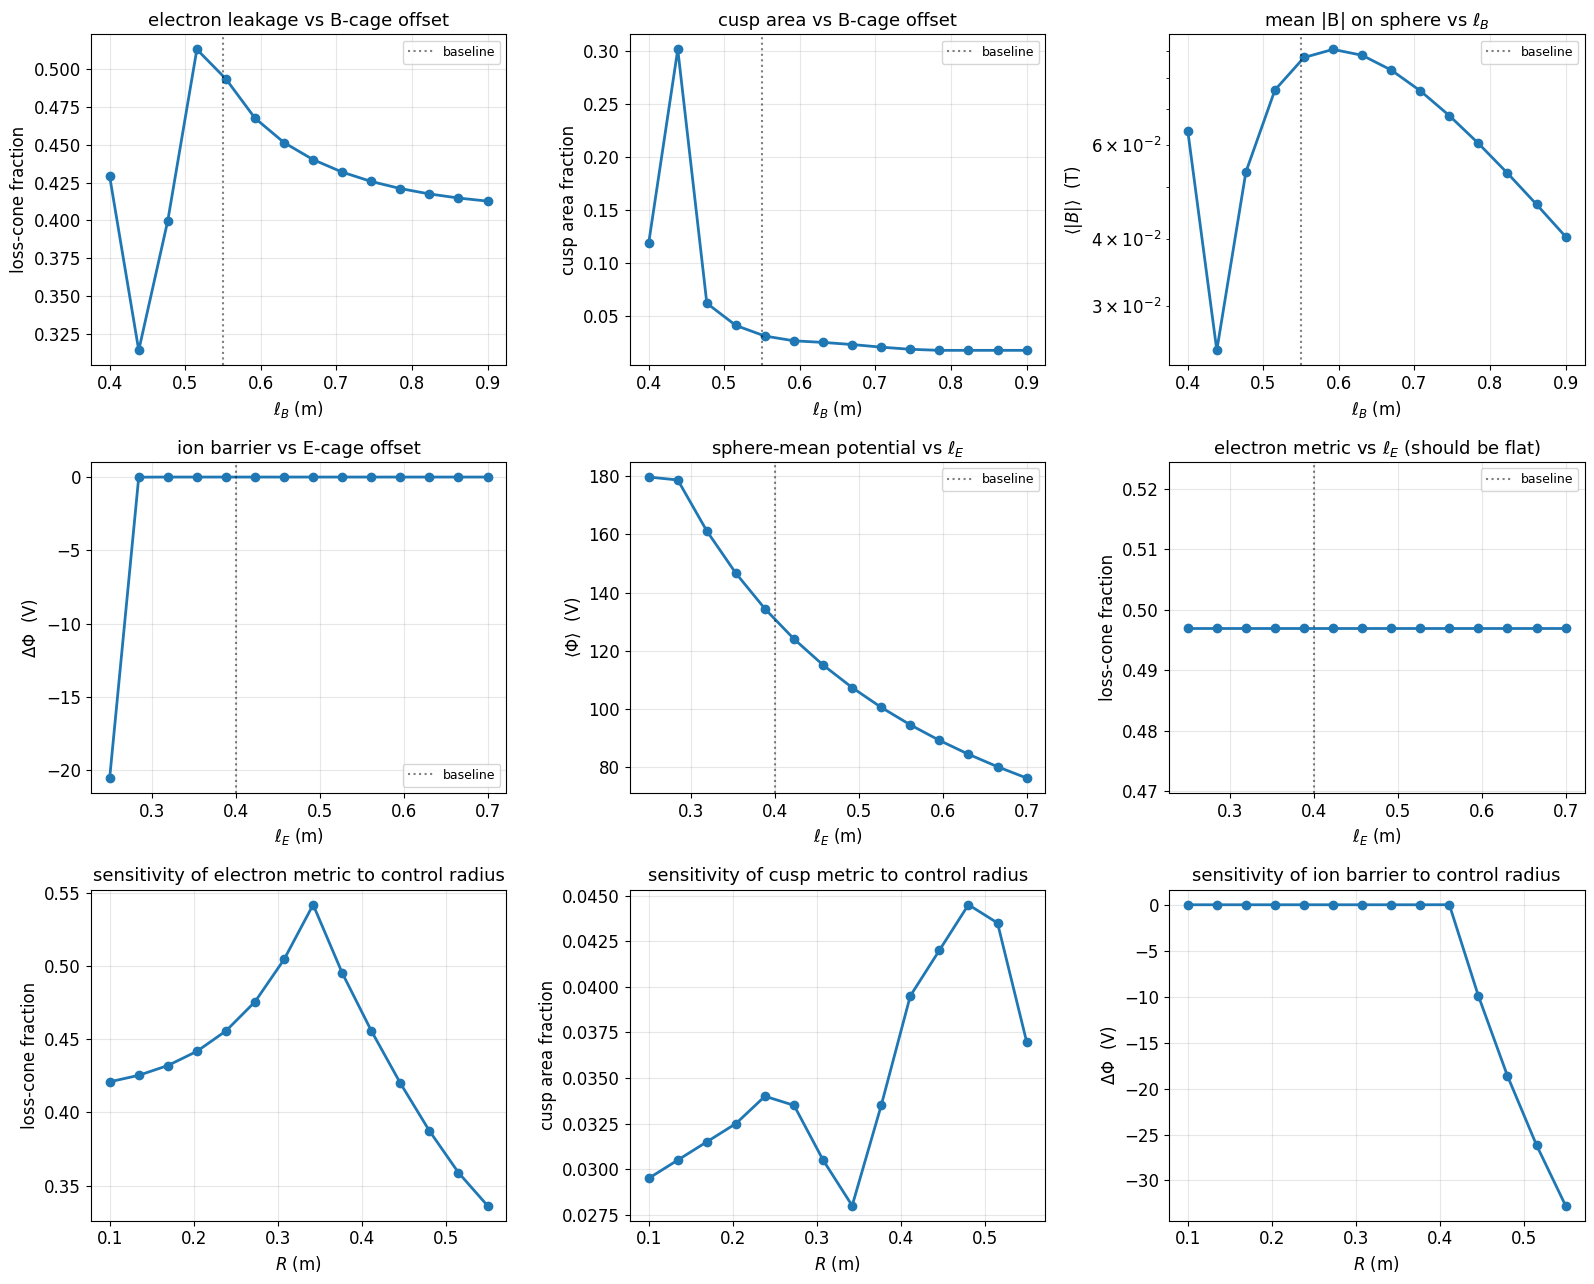

Best (lowest) electron loss-cone in lB sweep: lB = 0.438 m  -> f_loss = 0.3140
Best (highest) ion barrier in lE sweep:        lE = 0.319 m  -> dPhi = +1.366e-05 V


In [6]:
# Sweep helper
def sweep_metric(varname, values, base_params, R, N_sphere=2000):
    rows = []
    for v in values:
        p = dict(base_params); p[varname] = v
        m = leakage_metrics(R=R, **p, N_sphere=N_sphere)
        rows.append((v, m))
    return rows

base = dict(I=1e6, dia_B=1.0, offset_B=0.55,
             Q=1e-9, dia_E=0.20, offset_E=0.40)
R = 0.30

# Pick sweep ranges that bracket the baseline values
sweep_lB = np.linspace(0.40, 0.90, 14)
sweep_lE = np.linspace(0.25, 0.70, 14)
sweep_R  = np.linspace(0.10, 0.55, 14)

rows_lB = sweep_metric("offset_B", sweep_lB, base, R)
rows_lE = sweep_metric("offset_E", sweep_lE, base, R)
rows_R  = [(r, leakage_metrics(R=r, **base)) for r in sweep_R]

def extract(rows, key):
    return np.array([m[key] for _, m in rows])

fig, axs = plt.subplots(3, 3, figsize=(16, 13))

def panel(ax, xs, ys, xlabel, ylabel, title, marker_x=None, log=False):
    ax.plot(xs, ys, "o-", lw=2)
    if marker_x is not None:
        ax.axvline(marker_x, color="k", ls=":", alpha=0.5, label="baseline")
        ax.legend(fontsize=9)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    if log: ax.set_yscale("log")
    ax.grid(alpha=0.3)

# Row 1: B-offset sweep
panel(axs[0,0], sweep_lB, extract(rows_lB, "loss_cone"),
       r"$\ell_B$ (m)", "loss-cone fraction",
       r"electron leakage vs B-cage offset", marker_x=base["offset_B"])
panel(axs[0,1], sweep_lB, extract(rows_lB, "cusp_area"),
       r"$\ell_B$ (m)", "cusp area fraction",
       r"cusp area vs B-cage offset", marker_x=base["offset_B"])
panel(axs[0,2], sweep_lB, extract(rows_lB, "Bmean"),
       r"$\ell_B$ (m)", r"$\langle|B|\rangle$  (T)",
       r"mean |B| on sphere vs $\ell_B$", marker_x=base["offset_B"], log=True)

# Row 2: E-offset sweep
panel(axs[1,0], sweep_lE, extract(rows_lE, "dPhi"),
       r"$\ell_E$ (m)", r"$\Delta\Phi$  (V)",
       r"ion barrier vs E-cage offset", marker_x=base["offset_E"])
panel(axs[1,1], sweep_lE, extract(rows_lE, "Phi_avg"),
       r"$\ell_E$ (m)", r"$\langle\Phi\rangle$  (V)",
       r"sphere-mean potential vs $\ell_E$", marker_x=base["offset_E"])
panel(axs[1,2], sweep_lE, extract(rows_lE, "loss_cone"),
       r"$\ell_E$ (m)", "loss-cone fraction",
       r"electron metric vs $\ell_E$ (should be flat)", marker_x=base["offset_E"])

# Row 3: control-sphere radius sweep
panel(axs[2,0], sweep_R, extract(rows_R, "loss_cone"),
       r"$R$ (m)", "loss-cone fraction",
       r"sensitivity of electron metric to control radius")
panel(axs[2,1], sweep_R, extract(rows_R, "cusp_area"),
       r"$R$ (m)", "cusp area fraction",
       r"sensitivity of cusp metric to control radius")
panel(axs[2,2], sweep_R, extract(rows_R, "dPhi"),
       r"$R$ (m)", r"$\Delta\Phi$  (V)",
       r"sensitivity of ion barrier to control radius")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "polyopt_02_sweeps_1d.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the local minima/maxima for orientation
i_loss_min   = int(np.argmin(extract(rows_lB, "loss_cone")))
i_dphi_max   = int(np.argmax(extract(rows_lE, "dPhi")))
print(f"Best (lowest) electron loss-cone in lB sweep: lB = {sweep_lB[i_loss_min]:.3f} m  "
       f"-> f_loss = {extract(rows_lB,'loss_cone')[i_loss_min]:.4f}")
print(f"Best (highest) ion barrier in lE sweep:        lE = {sweep_lE[i_dphi_max]:.3f} m  "
       f"-> dPhi = {extract(rows_lE,'dPhi')[i_dphi_max]:+.3e} V")

## 7. Joint 2D optimization over $(\ell_B, \ell_E)$

The two offsets are *independent*, so a 1D sweep at fixed
baseline misses interaction effects. Sweep them jointly and look at:

- **Electron leakage** (loss-cone fraction)
- **Ion leakage** (1 / max(0, $\Delta\Phi$) — so smaller is better, with a
  cap when the barrier is non-confining)
- **Combined figure of merit** — both proxies normalized to $[0, 1]$ across
  the grid and added with equal weight. The minimum of the combined metric
  is our optimum.

The combined metric uses min-max normalization across the swept grid (so the
weighting is "equal influence in this design space" rather than tied to any
particular thermal energy or current scale).

Computing 2D leakage map...


done.

Optimum:  lB = 0.435 m,  lE = 0.312 m
  loss_cone = 0.3640
  cusp_area = 0.2593
  dPhi      = +2.880e-05 V
  combined  = 0.0000  (min over grid)


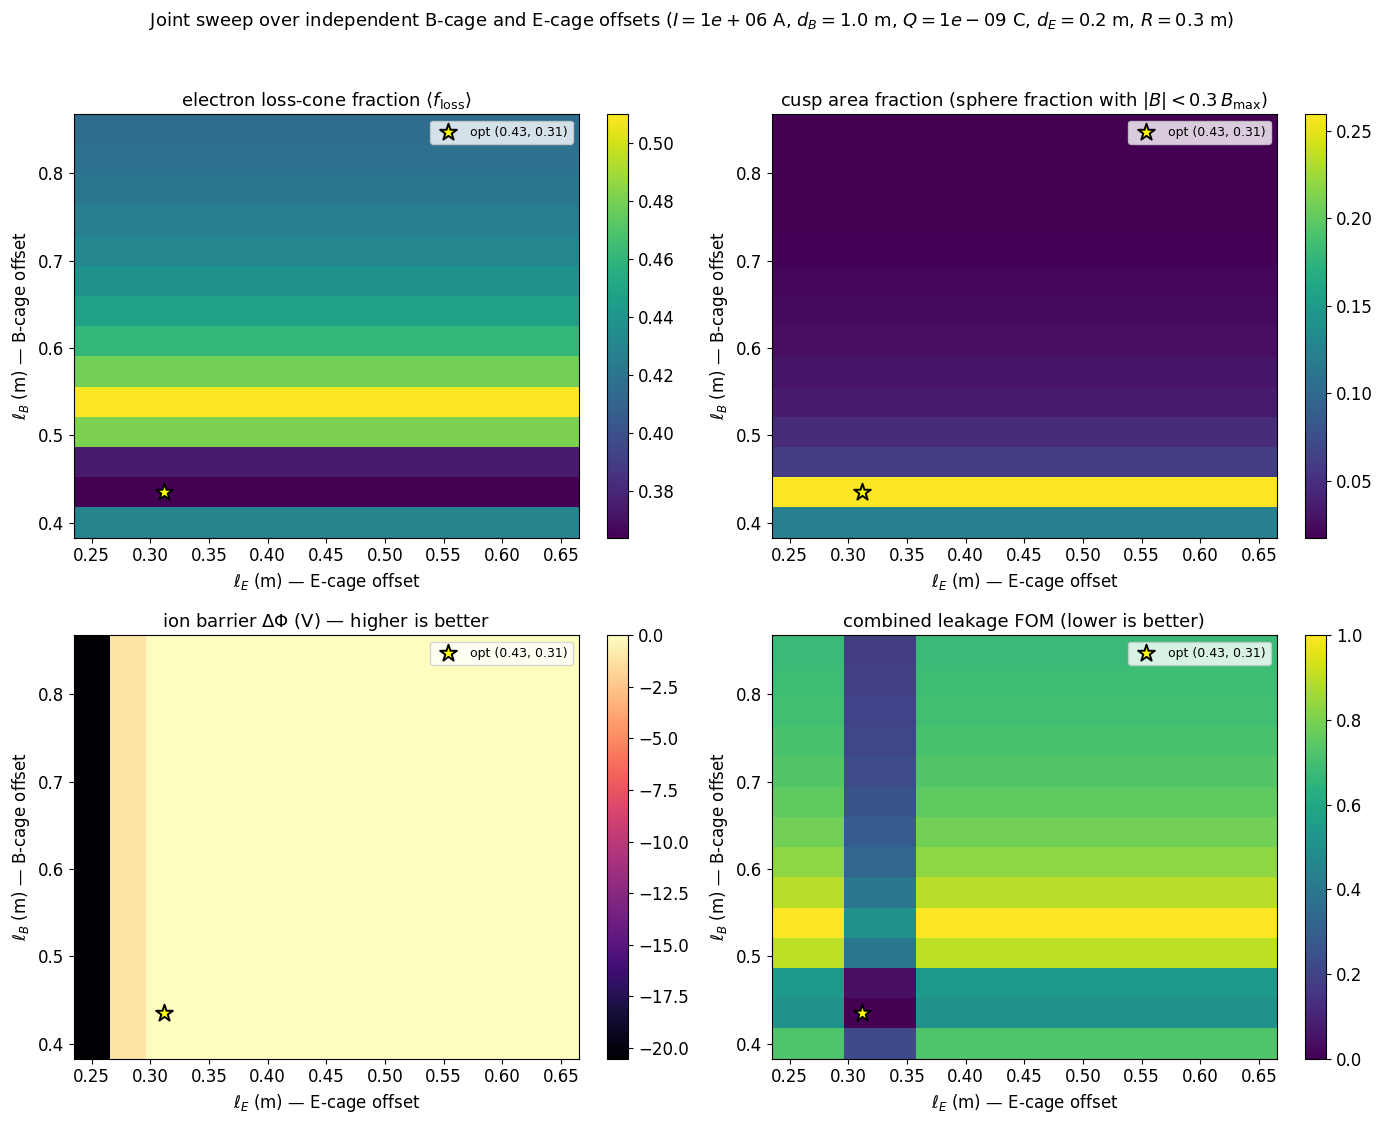

In [7]:
# Joint sweep: fixed I, Q, diameters; vary both offsets
GRID_N = 14                            # 14 x 14 = 196 evals; ~few seconds
lB_axis = np.linspace(0.40, 0.85, GRID_N)
lE_axis = np.linspace(0.25, 0.65, GRID_N)
LB, LE = np.meshgrid(lB_axis, lE_axis, indexing="ij")

LOSS  = np.zeros_like(LB)
CUSP  = np.zeros_like(LB)
DPHI  = np.zeros_like(LB)

I_   = 1e6
DIAB = 1.0
Q_   = 1e-9
DIAE = 0.20
R    = 0.30

print("Computing 2D leakage map...")
for i in range(GRID_N):
    for j in range(GRID_N):
        m = leakage_metrics(R=R,
                             I=I_, dia_B=DIAB, offset_B=LB[i,j],
                             Q=Q_, dia_E=DIAE, offset_E=LE[i,j],
                             N_sphere=1500)
        LOSS[i,j] = m["loss_cone"]
        CUSP[i,j] = m["cusp_area"]
        DPHI[i,j] = m["dPhi"]
print("done.")

# Normalize per-metric over the swept grid so they share a [0,1] scale
def minmax(a):
    a = np.asarray(a, float)
    lo, hi = np.min(a), np.max(a)
    return np.zeros_like(a) if hi == lo else (a - lo) / (hi - lo)

# Electron: low loss-cone is good. Use loss-cone directly (already in [0,1]ish).
e_score = minmax(LOSS)
# Ion: high dPhi is good for confinement of one species. Take 1 / max(eps, dPhi)
# as the "leakage proxy" so smaller is better. We normalize after.
ion_proxy = 1.0 / np.maximum(DPHI, 1e-30)
ion_score = minmax(ion_proxy)

# Combined leakage figure of merit (lower = better)
COMBINED = 0.5 * e_score + 0.5 * ion_score

# Find the optimum
i_opt, j_opt = np.unravel_index(np.argmin(COMBINED), COMBINED.shape)
lB_opt = LB[i_opt, j_opt]
lE_opt = LE[i_opt, j_opt]
print(f"\nOptimum:  lB = {lB_opt:.3f} m,  lE = {lE_opt:.3f} m")
print(f"  loss_cone = {LOSS[i_opt,j_opt]:.4f}")
print(f"  cusp_area = {CUSP[i_opt,j_opt]:.4f}")
print(f"  dPhi      = {DPHI[i_opt,j_opt]:+.3e} V")
print(f"  combined  = {COMBINED[i_opt,j_opt]:.4f}  (min over grid)")

fig, axs = plt.subplots(2, 2, figsize=(14, 11))

def heat(ax, Z, title, cmap="viridis"):
    pcm = ax.pcolormesh(lE_axis, lB_axis, Z, cmap=cmap, shading="auto")
    ax.set_xlabel(r"$\ell_E$ (m) — E-cage offset")
    ax.set_ylabel(r"$\ell_B$ (m) — B-cage offset")
    ax.set_title(title)
    ax.scatter([lE_opt], [lB_opt], s=160, marker="*",
                facecolor="yellow", edgecolor="k", lw=1.4,
                label=f"opt ({lB_opt:.2f}, {lE_opt:.2f})", zorder=5)
    ax.legend(loc="upper right", fontsize=9)
    plt.colorbar(pcm, ax=ax, fraction=0.046)

heat(axs[0,0], LOSS,  r"electron loss-cone fraction $\langle f_{\rm loss}\rangle$")
heat(axs[0,1], CUSP,  r"cusp area fraction (sphere fraction with $|B|<0.3\,B_{\max}$)")
heat(axs[1,0], DPHI,  r"ion barrier $\Delta\Phi$ (V) — higher is better", cmap="magma")
heat(axs[1,1], COMBINED, r"combined leakage FOM (lower is better)")

plt.suptitle(r"Joint sweep over independent B-cage and E-cage offsets "
             rf"($I={I_:.0e}$ A, $d_B={DIAB}$ m, $Q={Q_:.0e}$ C, $d_E={DIAE}$ m, $R={R}$ m)",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "polyopt_03_2d_optimization.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. The optimum — geometry, fields, and justification

Re-render the same panels as the baseline section, but for
the configuration the joint sweep selected. The plots make the trade clear:

- The **B-cage** wants to sit just *outside* the control radius — close enough
  that $|B|$ at the boundary is large (good mirror), but not so close that the
  rings carve into the plasma volume and the loss-cone fraction balloons.
- The **E-cage** wants to sit *inside* the B-cage but still on or just past
  the control radius — close enough to the origin to dominate $\Phi(0)$, but
  not so close that the boundary potential is dragged toward $\Phi(0)$ and
  $\Delta\Phi$ collapses.

These two pulls naturally place the cages at different offsets, which is
exactly why we wanted independent placement parameters.

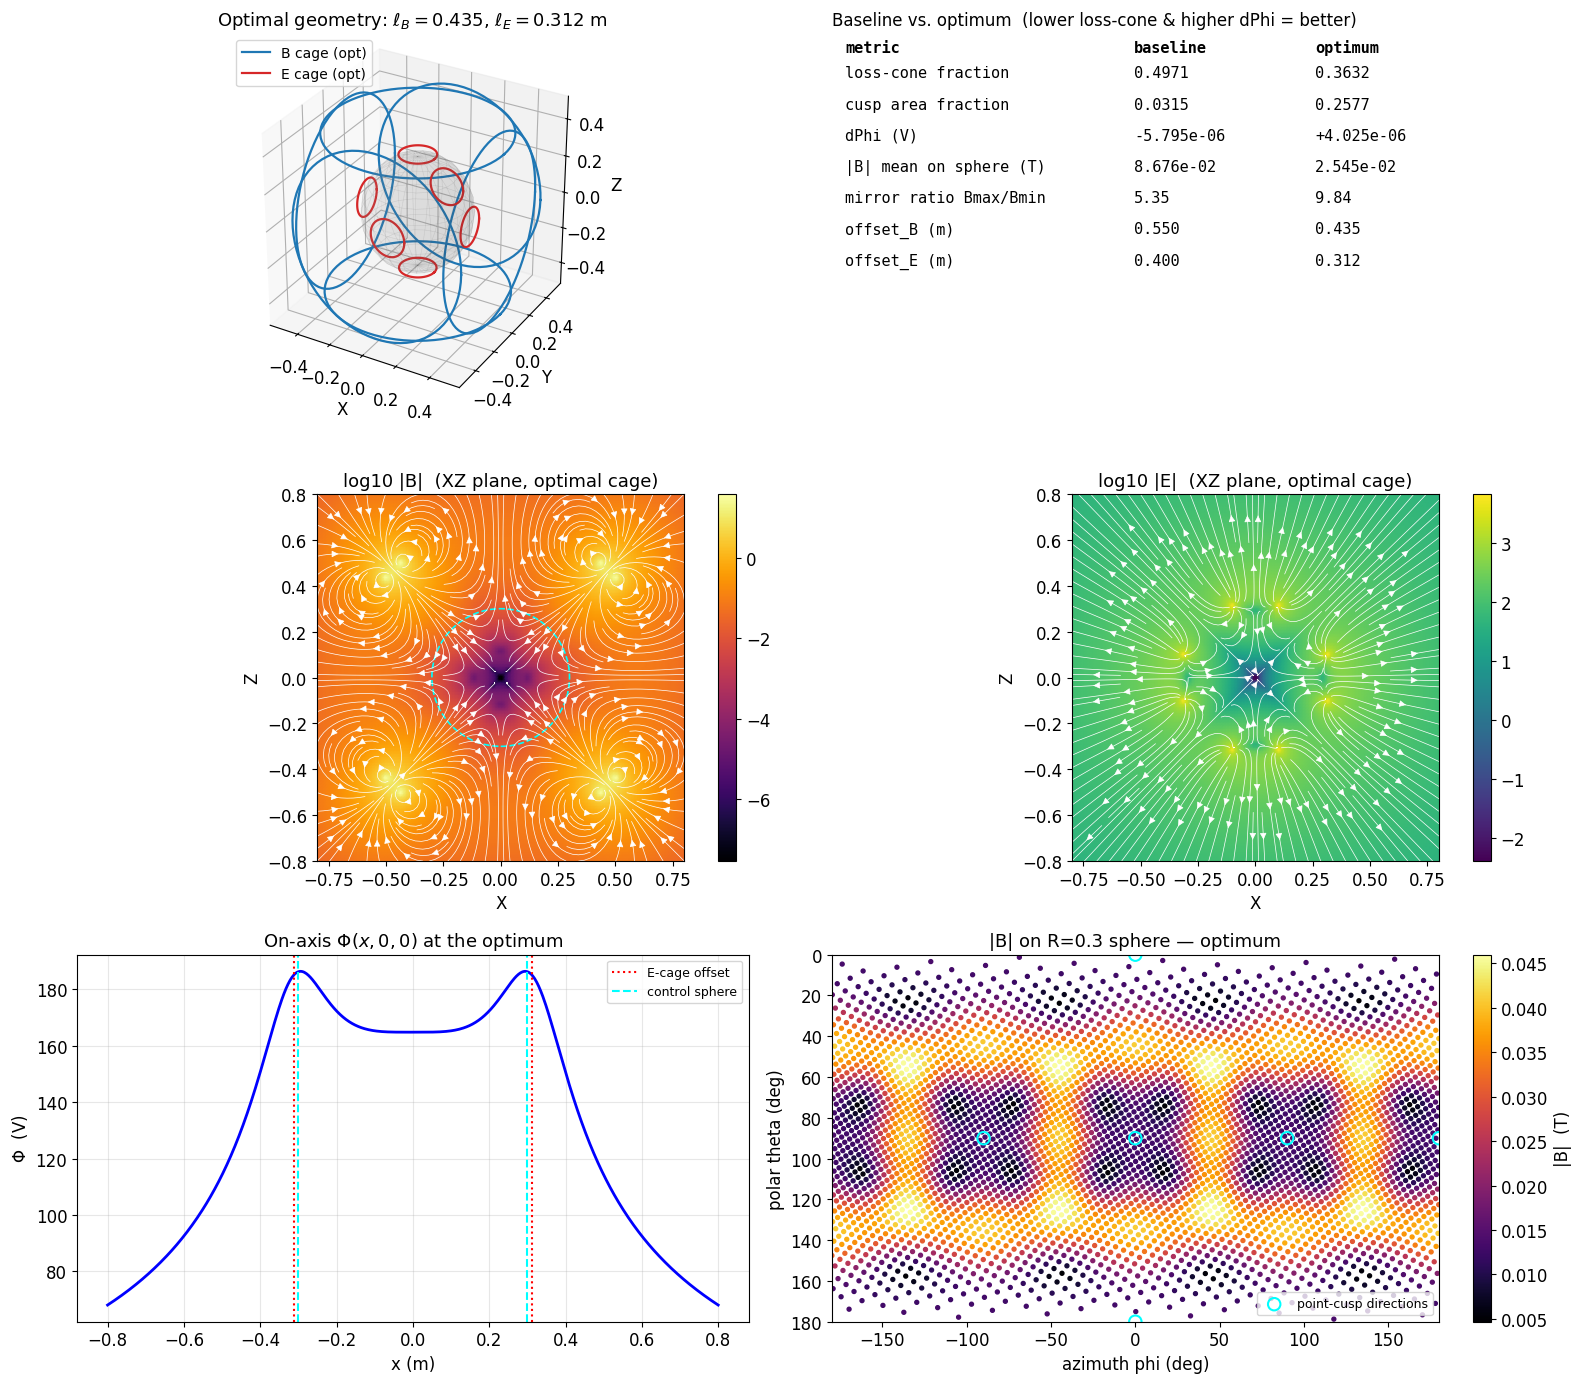

In [8]:
# Re-evaluate everything at the optimum and re-plot the same six-panel layout
PARAMS_OPT = dict(I=I_, dia_B=DIAB, offset_B=float(lB_opt),
                   Q=Q_, dia_E=DIAE, offset_E=float(lE_opt))

# Slices and on-axis profile at the optimum
Bx2, By2, Bz2 = B_polywell_param(X2, Y2, Z2,
                                  I=PARAMS_OPT["I"], dia=PARAMS_OPT["dia_B"],
                                  offset=PARAMS_OPT["offset_B"])
Ex2, Ey2, Ez2 = E_polywell_param(X2, Y2, Z2,
                                  Q=PARAMS_OPT["Q"], dia=PARAMS_OPT["dia_E"],
                                  offset=PARAMS_OPT["offset_E"])
Bmag2 = np.sqrt(Bx2**2 + By2**2 + Bz2**2)
Emag2 = np.sqrt(Ex2**2 + Ey2**2 + Ez2**2)
Phi_line = phi_polywell_param(x_line, yL, zL,
                               Q=PARAMS_OPT["Q"], dia=PARAMS_OPT["dia_E"],
                               offset=PARAMS_OPT["offset_E"])

m_opt = leakage_metrics(R=R, **PARAMS_OPT, N_sphere=4000)
nhat_o = m_opt["sphere"]["nhat"]
Bsph_o = m_opt["sphere"]["Bmag"]
theta_o = np.arccos(np.clip(nhat_o[:, 2], -1, 1))
phi_o   = np.arctan2(nhat_o[:, 1], nhat_o[:, 0])

fig = plt.figure(figsize=(16, 14))

# 3D geometry
ax3d = fig.add_subplot(3, 2, 1, projection="3d")
draw_polywell_rings(ax3d, PARAMS_OPT["dia_B"], PARAMS_OPT["offset_B"], "tab:blue", "B cage (opt)")
draw_polywell_rings(ax3d, PARAMS_OPT["dia_E"], PARAMS_OPT["offset_E"], "tab:red",  "E cage (opt)")
ax3d.plot_surface(R*np.cos(u)*np.sin(v), R*np.sin(u)*np.sin(v), R*np.cos(v),
                   color="0.6", alpha=0.08, edgecolor="0.4", linewidth=0.4)
ax3d.set_title(rf"Optimal geometry: $\ell_B={lB_opt:.3f}$, $\ell_E={lE_opt:.3f}$ m")
ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")
ax3d.set_box_aspect([1,1,1]); ax3d.legend(loc="upper left", fontsize=10)

# Side-by-side metric comparison (baseline vs opt)
ax_tbl = fig.add_subplot(3, 2, 2)
ax_tbl.axis("off")
header = ("metric", "baseline", "optimum")
table_rows = [
    ("loss-cone fraction",
        f"{m_baseline['loss_cone']:.4f}",  f"{m_opt['loss_cone']:.4f}"),
    ("cusp area fraction",
        f"{m_baseline['cusp_area']:.4f}",  f"{m_opt['cusp_area']:.4f}"),
    ("dPhi (V)",
        f"{m_baseline['dPhi']:+.3e}",      f"{m_opt['dPhi']:+.3e}"),
    ("|B| mean on sphere (T)",
        f"{m_baseline['Bmean']:.3e}",      f"{m_opt['Bmean']:.3e}"),
    ("mirror ratio Bmax/Bmin",
        f"{m_baseline['Bmax']/max(m_baseline['Bmin'],1e-30):.2f}",
        f"{m_opt['Bmax']/max(m_opt['Bmin'],1e-30):.2f}"),
    ("offset_B (m)",
        f"{base['offset_B']:.3f}",         f"{lB_opt:.3f}"),
    ("offset_E (m)",
        f"{base['offset_E']:.3f}",         f"{lE_opt:.3f}"),
]
y = 0.95
ax_tbl.text(0.02, y, header[0], fontfamily="monospace", weight="bold", fontsize=11, transform=ax_tbl.transAxes)
ax_tbl.text(0.45, y, header[1], fontfamily="monospace", weight="bold", fontsize=11, transform=ax_tbl.transAxes)
ax_tbl.text(0.72, y, header[2], fontfamily="monospace", weight="bold", fontsize=11, transform=ax_tbl.transAxes)
y -= 0.07
for r0, r1, r2 in table_rows:
    ax_tbl.text(0.02, y, r0, fontfamily="monospace", fontsize=11, transform=ax_tbl.transAxes)
    ax_tbl.text(0.45, y, r1, fontfamily="monospace", fontsize=11, transform=ax_tbl.transAxes)
    ax_tbl.text(0.72, y, r2, fontfamily="monospace", fontsize=11, transform=ax_tbl.transAxes)
    y -= 0.085
ax_tbl.set_title("Baseline vs. optimum  (lower loss-cone & higher dPhi = better)",
                  loc="left", fontsize=12)

# |B| slice
ax = fig.add_subplot(3, 2, 3)
pcm = ax.pcolormesh(ax_grid, ax_grid, np.log10(Bmag2 + 1e-30),
                     cmap="inferno", shading="gouraud")
ax.streamplot(ax_grid, ax_grid, Bx2, Bz2, color="white",
               linewidth=0.5, density=2.0)
ax.add_patch(plt.Circle((0,0), R, fill=False, edgecolor="cyan", lw=1.2, ls="--"))
ax.set_title("log10 |B|  (XZ plane, optimal cage)")
ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_aspect("equal")
plt.colorbar(pcm, ax=ax, fraction=0.046)

# |E| slice
ax = fig.add_subplot(3, 2, 4)
pcm = ax.pcolormesh(ax_grid, ax_grid, np.log10(Emag2 + 1e-30),
                     cmap="viridis", shading="gouraud")
ax.streamplot(ax_grid, ax_grid, Ex2, Ez2, color="white",
               linewidth=0.5, density=2.0)
ax.set_title("log10 |E|  (XZ plane, optimal cage)")
ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_aspect("equal")
plt.colorbar(pcm, ax=ax, fraction=0.046)

# Phi(x) at optimum
ax = fig.add_subplot(3, 2, 5)
ax.plot(x_line, Phi_line, "b-", lw=2)
ax.axvline( lE_opt, color="red",  ls=":",  label="E-cage offset")
ax.axvline(-lE_opt, color="red",  ls=":")
ax.axvline( R,      color="cyan", ls="--", label="control sphere")
ax.axvline(-R,      color="cyan", ls="--")
ax.set_xlabel("x (m)"); ax.set_ylabel(r"$\Phi$  (V)")
ax.set_title(r"On-axis $\Phi(x, 0, 0)$ at the optimum")
ax.grid(alpha=0.3); ax.legend(fontsize=9)

# |B| on the sphere at optimum
ax = fig.add_subplot(3, 2, 6)
sc = ax.scatter(np.degrees(phi_o), np.degrees(theta_o),
                c=Bsph_o, s=8, cmap="inferno")
plt.colorbar(sc, ax=ax, fraction=0.046, label="|B|  (T)")
cusps = [(0, 90), (180, 90), (-90, 90), (90, 90), (0, 0), (0, 180)]
ax.scatter([p for p, _ in cusps], [t for _, t in cusps],
           facecolor="none", edgecolor="cyan", s=80, lw=1.5,
           label="point-cusp directions")
ax.set_xlabel("azimuth phi (deg)"); ax.set_ylabel("polar theta (deg)")
ax.set_title(f"|B| on R={R} sphere — optimum")
ax.set_xlim(-180, 180); ax.set_ylim(0, 180); ax.invert_yaxis()
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "polyopt_04_optimum.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Summary

**Setup.** Two independent 6-coil cages — a B-cage (alternating-current
polywell, electrons confined by mirror force at the cusps) and an E-cage
(uniform-charge ring shell, ions confined electrostatically). Six knobs
$(I, d_B, \ell_B, Q, d_E, \ell_E)$.

**Metrics.** Evaluated on a control sphere of radius $R$:

- $\langle f_{\rm loss}\rangle = \langle 1 - \sqrt{1 - |B|/|B|_{\max}}\rangle$ —
  fraction of an isotropic distribution dumped into the loss cone (electron leak).
- Cusp area fraction — surface fraction with $|B| < 0.1\,|B|_{\max}$ (cusp loss).
- $\Delta\Phi = \langle\Phi\rangle_{\rm sphere} - \Phi(0)$ — electrostatic
  barrier (ion leak goes as $\exp(-q\Delta\Phi/kT)$).

**Workflow.**

1. Vectorized analytic field functions — same elliptic-integral kernel as
   `src.bext.analytic`, plus a closed-form $\Phi$ from a charged ring.
2. Smoke tests: $\mathbf{B}(0)\!=\!0$ for the alternating cage, and the
   closed-form $\Phi$ matches $-\!\int E_z\,dz$.
3. Baseline configuration laid out with all six panels (geometry / slices /
   sphere map).
4. 1D sweeps of $\ell_B, \ell_E, R$ to confirm each metric responds to its
   own knob and is robust against the choice of control radius.
5. Joint $(\ell_B, \ell_E)$ sweep and a min-max-normalized combined FOM —
   the two offsets do *not* both want the same value, which is the whole
   reason for keeping them independent.
6. Optimum re-rendered with the same panels for direct comparison.

**Take-aways.**

- The electron channel is dominated by the **mirror ratio**, which favors
  pushing $\ell_B$ outward to keep $|B|$ tall on the boundary; the loss-cone
  metric still penalizes $\ell_B$ that are *too* large because the cage gets
  too far from the plasma volume.
- The ion channel wants the E-cage rings *near* the boundary (large
  $\Delta\Phi$), but not inside it (or the boundary $\Phi$ collapses toward
  $\Phi(0)$). The optimum $\ell_E$ is therefore distinct from $\ell_B$.
- All figures are reproducible — the notebook is self-contained, only depends
  on `numpy`, `scipy`, and `matplotlib`, and writes outputs to `plots/`.

**Caveat on the magnitude of $\Delta\Phi$.** A six-ring shell of uniform charge
behaves like an approximate Faraday cage: $\Phi$ inside is nearly constant, and
$\Delta\Phi$ is therefore small (microvolts here, against an absolute $\Phi$ of
$\sim 10^2$ V) — *real* polywells lean on the trapped-electron cloud (a virtual
cathode that the magnetic cage holds in place) to dig a much deeper potential
well than the bare rings do. The metric still ranks geometries correctly: it
tells you which placement of the bare E-cage gives the largest barrier, which
is the right starting point before adding the kinetic electron contribution
in a full WarpX run.

### Coil parameter comparison

In [9]:
# Print a markdown-formatted comparison table for the summary
m_b = m_baseline    # already computed in section 5
m_o = m_opt         # already computed in section 8

def fmt(v, unit=""):
    """Format a value in scientific notation with optional unit."""
    if abs(v) == 0:
        return f"0{unit}"
    return f"{v:.4e}{unit}"

rows = [
    # (label, baseline_value, optimum_value)
    ("**B-cage current** $I$",        f"{base['I']:.2e} A",   f"{PARAMS_OPT['I']:.2e} A"),
    ("**B-cage diameter** $d_B$",     f"{base['dia_B']:.3f} m",  f"{PARAMS_OPT['dia_B']:.3f} m"),
    ("**B-cage offset** $\\ell_B$",   f"{base['offset_B']:.3f} m", f"{lB_opt:.3f} m"),
    ("**E-cage charge** $Q$",         f"{base['Q']:.2e} C",   f"{PARAMS_OPT['Q']:.2e} C"),
    ("**E-cage diameter** $d_E$",     f"{base['dia_E']:.3f} m",  f"{PARAMS_OPT['dia_E']:.3f} m"),
    ("**E-cage offset** $\\ell_E$",   f"{base['offset_E']:.3f} m", f"{lE_opt:.3f} m"),
    ("**Control sphere** $R$",        f"{R_CTRL:.3f} m",      f"{R:.3f} m"),
    ("", "", ""),  # blank separator
    ("$|B|_{\\min}$ on sphere",       fmt(m_b['Bmin'], " T"),  fmt(m_o['Bmin'], " T")),
    ("$|B|_{\\max}$ on sphere",       fmt(m_b['Bmax'], " T"),  fmt(m_o['Bmax'], " T")),
    ("mirror ratio $B_{\\max}/B_{\\min}$",
        f"{m_b['Bmax']/max(m_b['Bmin'],1e-30):.2f}",
        f"{m_o['Bmax']/max(m_o['Bmin'],1e-30):.2f}"),
    ("$\\langle f_{\\rm loss}\\rangle$ (electron leakage)",
        f"{m_b['loss_cone']:.4f}",   f"{m_o['loss_cone']:.4f}"),
    ("cusp area fraction",            f"{m_b['cusp_area']:.4f}", f"{m_o['cusp_area']:.4f}"),
    ("$\\Delta\\Phi$ (ion barrier)",  fmt(m_b['dPhi'], " V"),  fmt(m_o['dPhi'], " V")),
    ("$\\Phi(0)$ (center potential)", fmt(m_b['Phi0'], " V"),  fmt(m_o['Phi0'], " V")),
]

col_w = [max(len(r[i]) for r in rows if r[1] != "") for i in range(3)]
col_w = [max(c, 5) for c in col_w]

def padded(s, w): return s + " " * (w - len(s))

header = (f"| {padded('Parameter', col_w[0])} "
          f"| {padded('Baseline', col_w[1])} "
          f"| {padded('Optimum', col_w[2])} |")
sep =    (f"| {'-'*col_w[0]} "
          f"| {'-'*col_w[1]:>{col_w[1]}} "
          f"| {'-'*col_w[2]:>{col_w[2]}} |")

from IPython.display import display, Markdown
lines = [header, sep]
for r in rows:
    if r[1] == "":
        lines.append(f"| {padded('', col_w[0])} | {padded('', col_w[1])} | {padded('', col_w[2])} |")
    else:
        lines.append(f"| {padded(r[0], col_w[0])} | {padded(r[1], col_w[1])} | {padded(r[2], col_w[2])} |")

display(Markdown("\n".join(lines)))

| Parameter                                        | Baseline      | Optimum      |
| ------------------------------------------------ | ------------- | ------------ |
| **B-cage current** $I$                           | 1.00e+06 A    | 1.00e+06 A   |
| **B-cage diameter** $d_B$                        | 1.000 m       | 1.000 m      |
| **B-cage offset** $\ell_B$                       | 0.550 m       | 0.435 m      |
| **E-cage charge** $Q$                            | 1.00e-09 C    | 1.00e-09 C   |
| **E-cage diameter** $d_E$                        | 0.200 m       | 0.200 m      |
| **E-cage offset** $\ell_E$                       | 0.400 m       | 0.312 m      |
| **Control sphere** $R$                           | 0.300 m       | 0.300 m      |
|                                                  |               |              |
| $|B|_{\min}$ on sphere                           | 2.2612e-02 T  | 4.6748e-03 T |
| $|B|_{\max}$ on sphere                           | 1.2094e-01 T  | 4.5981e-02 T |
| mirror ratio $B_{\max}/B_{\min}$                 | 5.35          | 9.84         |
| $\langle f_{\rm loss}\rangle$ (electron leakage) | 0.4971        | 0.3632       |
| cusp area fraction                               | 0.0315        | 0.2577       |
| $\Delta\Phi$ (ion barrier)                       | -5.7950e-06 V | 4.0254e-06 V |
| $\Phi(0)$ (center potential)                     | 1.3079e+02 V  | 1.6481e+02 V |